# Imports

In [31]:
import pandas as pd
import bs4
import requests
import re
import time
import numpy as np
import matplotlib.pyplot as plt 
import os
import PIL
import io
import random

from src.load_images import prepare_image_column, display_artwork_image
from src.gan_trainer import ArtGANTrainer

import torch
from torch.utils.data import TensorDataset, DataLoader
from torchvision.utils import make_grid

# Data

In [32]:
df = pd.read_csv('data/art_catalog.xlsx - catalog.csv')

In [33]:
df.head(2)

,AUTHOR,BORN-DIED,TITLE,DATE,TECHNIQUE,LOCATION,URL,FORM,TYPE,SCHOOL,TIMEFRAME
0,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Venus and Adonis,1574-88,"Oil on canvas, 68 x 95 cm","Fogg Art Museum, Harvard University, Cambridge",https://www.wga.hu/html/a/aachen/adonis.html,painting,mythological,German,1601-1650
1,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Allegory,1598,"Oil on copper, 56 x 47 cm","Alte Pinakothek, Munich",https://www.wga.hu/html/a/aachen/allegory.html,painting,mythological,German,1601-1650


In [34]:
painting_df = df[df['FORM'] == 'painting']
painting_df.head(2)

,AUTHOR,BORN-DIED,TITLE,DATE,TECHNIQUE,LOCATION,URL,FORM,TYPE,SCHOOL,TIMEFRAME
0,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Venus and Adonis,1574-88,"Oil on canvas, 68 x 95 cm","Fogg Art Museum, Harvard University, Cambridge",https://www.wga.hu/html/a/aachen/adonis.html,painting,mythological,German,1601-1650
1,"AACHEN, Hans von","(b. 1552, Köln, d. 1615, Praha)",Allegory,1598,"Oil on copper, 56 x 47 cm","Alte Pinakothek, Munich",https://www.wga.hu/html/a/aachen/allegory.html,painting,mythological,German,1601-1650


In [35]:
painting_df = painting_df.drop(columns=['DATE', 'BORN-DIED', 'LOCATION', 'TECHNIQUE', 'URL', 'SCHOOL', 'TIMEFRAME'])

In [36]:
print(painting_df.shape)
painting_df.head(2)

(32438, 4)


,AUTHOR,TITLE,FORM,TYPE
0,"AACHEN, Hans von",Venus and Adonis,painting,mythological
1,"AACHEN, Hans von",Allegory,painting,mythological


In [37]:
painting_df.TYPE.value_counts(normalize=True)

TYPE
religious       0.416703
portrait        0.148283
landscape       0.126487
mythological    0.098711
genre           0.085455
still-life      0.043313
other           0.029903
historical      0.029071
interior        0.019607
study           0.002466
Name: proportion, dtype: float64

In [38]:
painting_df.TYPE.value_counts()

TYPE
religious       13517
portrait         4810
landscape        4103
mythological     3202
genre            2772
still-life       1405
other             970
historical        943
interior          636
study              80
Name: count, dtype: int64

In [39]:
painting_df.to_csv('data/full_painting_catalog.csv', index=False)

In [40]:
painting_df.iloc[0]

AUTHOR    AACHEN, Hans von
TITLE     Venus and Adonis
FORM              painting
TYPE          mythological
Name: 0, dtype: object

In [41]:
choosen_types_df = painting_df[painting_df['TYPE'].isin(['religious', 'portrait', 'landscape', 'mythological'])]
print(choosen_types_df.TYPE.value_counts())


TYPE
religious       13517
portrait         4810
landscape        4103
mythological     3202
Name: count, dtype: int64


In [42]:

choosen_types_df.to_csv('data/choosen_types_painting_catalog.csv', index=False)

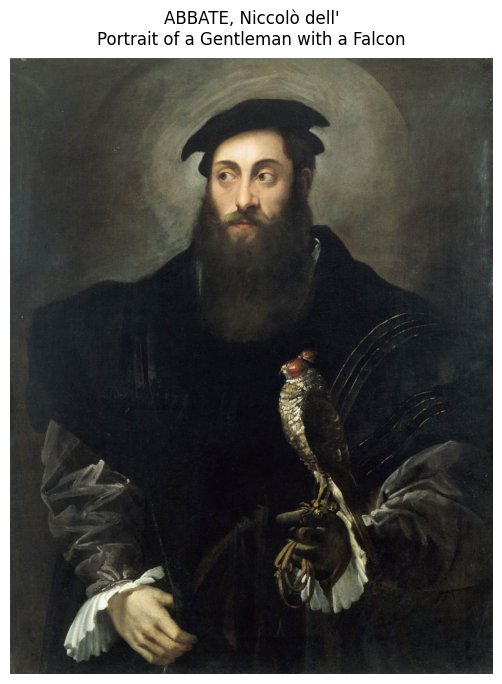

Loaded: /Users/julienrm/Workspace/M2/GANISME/app/data/img/ABBATE_Niccol_dell-Portrait_of_a_Gentleman_with_a_Falcon.jpg


In [43]:
display_artwork_image(df, 42)  # Display row at index 42

In [ ]:
# p = "64"

In [45]:
# processed_painting_df = prepare_image_column(painting_df, "IMAGE", p)

Transform '64' processed 31062/32438 images.
Dropped 1376 rows due to missing or unreadable images.


In [46]:
# processed_painting_df.head(2)

In [47]:
# processed_painting_df.shape

In [48]:
# processed_painting_df.to_csv(f'data/{p}image_catalog.csv', index=False)

## models

### Training Base Model

In [49]:
# images = torch.from_numpy(
#     np.stack(processed_painting_df["IMAGE"].to_numpy())
# ).permute(0, 3, 1, 2)            # (N, C, H, W) = (N, 3, 64, 64)

# dataset = TensorDataset(images)
# dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

In [50]:
# trainer = ArtGANTrainer(
#     mode="basic",
#     image_size=64,
#     channels=3,
#     latent_dim=128,
#     fid_every=5,      # set >epochs to skip if torchmetrics missing
#     fid_samples=256,
# )

In [51]:
# history = trainer.train(dataloader, epochs=50, lr=2e-4)
# trainer.plot_history()

In [52]:
# samples = trainer.sample(16).cpu()
# grid = (samples + 1) / 2  # back to [0,1] for matplotlib

# # samples = trainer.sample(16).cpu()
# # grid = (samples + 1) / 2  # back to [0,1] for display
# fig, ax = plt.subplots(figsize=(6, 6))
# ax.imshow(make_grid(grid, nrow=4).permute(1, 2, 0).numpy())
# ax.axis("off")
# plt.show()

# plt.savefig(f'output_{p}.png', bbox_inches='tight', dpi=150)

In [53]:
# # 1) Load & resize as 28×28 to keep the basic GAN fast


#     dataset = TensorDataset(images)
#     dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)
#   - Train the “basic” mode:

#     trainer = ArtGANTrainer(
#         mode="basic",
#         image_size=28,
#         channels=3,
#         latent_dim=128,
#         fid_every=5,     # skip or raise if torchmetrics unavailable
#         fid_samples=256, # optional
#     )

#     history = trainer.train(dataloader, epochs=50, lr=2e-4)
#     trainer.plot_history()
#   - Generate samples right away:

#     samples = trainer.sample(16).cpu()  # in [-1, 1]
#     grid = (samples + 1) / 2            # back to [0, 1] for plotting

### training 128

In [ ]:
p = "128x128"

processed_painting_df = prepare_image_column(painting_df, "IMAGE", p)

print(processed_painting_df.shape)
print(processed_painting_df.head(2))

processed_painting_df.to_csv(f'data/{p}image_catalog.csv', index=False)

images = torch.from_numpy(
    np.stack(processed_painting_df["IMAGE"].to_numpy())
).permute(0, 3, 1, 2).float()

dataset = TensorDataset(images)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

In [ ]:
trainer = ArtGANTrainer(
      mode="basic",
      image_size=128,
      early_stopping_metric="fid",
      early_stopping_patience=40,
      fid_every=1,
      fid_samples=256,
)




/Users/julienrm/.pyenv/versions/ganisme/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


[Epoch 1/300] D_loss: 1.1580 G_loss: 1.4456 FID: 435.04 Inception: 1.275
[Epoch 2/300] D_loss: 1.2324 G_loss: 1.1120 FID: 413.93 Inception: 1.307
[Epoch 3/300] D_loss: 1.2659 G_loss: 1.1884 FID: 376.24 Inception: 1.557
[Epoch 4/300] D_loss: 1.2917 G_loss: 1.1200 FID: 382.82 Inception: 1.705
[Epoch 5/300] D_loss: 1.2937 G_loss: 1.1304 FID: 387.15 Inception: 1.859
[Epoch 6/300] D_loss: 1.3078 G_loss: 1.0833 FID: 375.30 Inception: 2.010
[Epoch 7/300] D_loss: 1.3054 G_loss: 1.0310 FID: 360.14 Inception: 1.974
[Epoch 8/300] D_loss: 1.2959 G_loss: 1.0870 FID: 378.18 Inception: 2.070
[Epoch 9/300] D_loss: 1.3117 G_loss: 1.0231 FID: 356.83 Inception: 2.171
[Epoch 10/300] D_loss: 1.3162 G_loss: 0.9912 FID: 354.50 Inception: 2.258
[Epoch 11/300] D_loss: 1.3246 G_loss: 0.9694 FID: 331.26 Inception: 2.202
[Epoch 12/300] D_loss: 1.3231 G_loss: 0.9641 FID: 352.84 Inception: 2.297
[Epoch 13/300] D_loss: 1.3229 G_loss: 0.9273 FID: 341.79 Inception: 2.327
[Epoch 14/300] D_loss: 1.3201 G_loss: 0.9385 FI

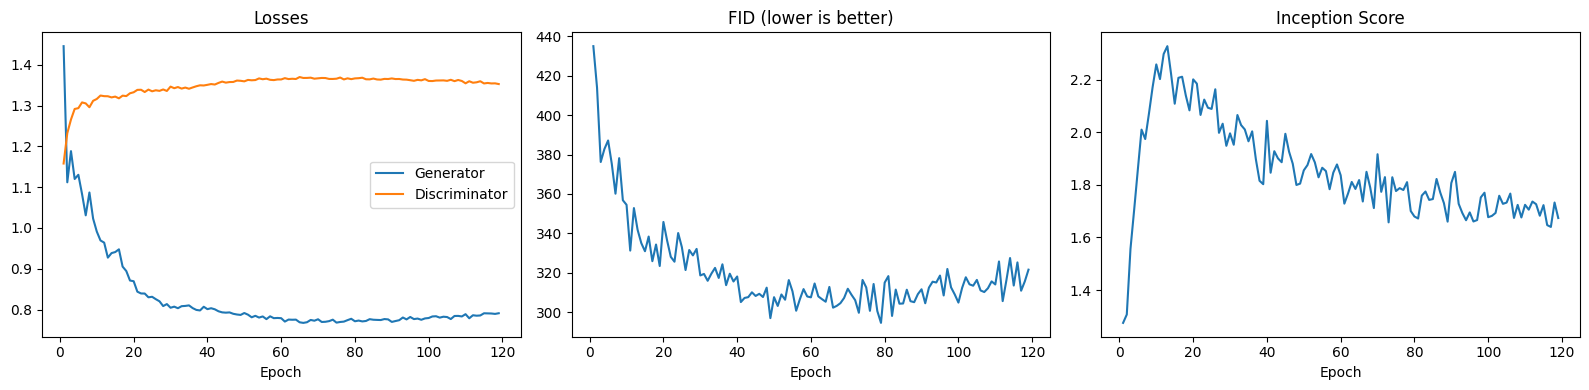

In [ ]:
history = trainer.train(dataloader, epochs=300, lr=2e-4)
trainer.plot_history()


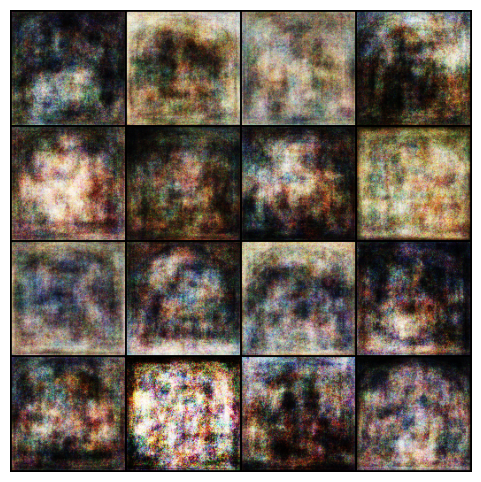

<Figure size 640x480 with 0 Axes>

In [70]:
samples = trainer.sample(16).cpu()
grid = (samples + 1) / 2  # back to [0,1] for matplotlib

# samples = trainer.sample(16).cpu()
# grid = (samples + 1) / 2  # back to [0,1] for display
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(make_grid(grid, nrow=4).permute(1, 2, 0).numpy())
ax.axis("off")
plt.show()

plt.savefig(f'output_{p}.png', bbox_inches='tight', dpi=150)

In [ ]:
trainer.save_checkpoint("model/checkpoints/basic_128.pt")

### training on dcgan

In [74]:
p = "64x64"

processed_painting_df = prepare_image_column(painting_df, "IMAGE", p)

print(processed_painting_df.shape)
print(processed_painting_df.head(2))

processed_painting_df.to_csv(f'data/{p}image_catalog.csv', index=False)

images = torch.from_numpy(
    np.stack(processed_painting_df["IMAGE"].to_numpy())
).permute(0, 3, 1, 2).float()

dataset = TensorDataset(images)
dataloader = DataLoader(dataset, batch_size=128, shuffle=True, drop_last=True)

Transform '64x64' processed 31062/32438 images.
Dropped 1376 rows due to missing or unreadable images.
(31062, 5)
             AUTHOR             TITLE      FORM          TYPE  \
0  AACHEN, Hans von  Venus and Adonis  painting  mythological   
1  AACHEN, Hans von          Allegory  painting  mythological   

                                               IMAGE  
0  [[[0.2627451, 0.2509804, 0.19215687], [0.23137...  
1  [[[0.23137255, 0.24313726, 0.18039216], [0.215...  


In [77]:
dcgan_trainer = ArtGANTrainer(
      mode="dcgan",
      image_size=64,
      early_stopping_metric="fid",
      early_stopping_patience=10,
      fid_every=1,
      fid_samples=256,
)

/Users/julienrm/.pyenv/versions/ganisme/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


[Epoch 1/50] D_loss: 0.8191 G_loss: 7.0965 FID: 326.83 Inception: 1.870
[Epoch 2/50] D_loss: 0.9012 G_loss: 2.8132 FID: 404.87 Inception: 2.024
[Epoch 3/50] D_loss: 0.7474 G_loss: 3.4232 FID: 380.04 Inception: 1.994
[Epoch 4/50] D_loss: 0.6798 G_loss: 3.9522 FID: 352.46 Inception: 2.163
[Epoch 5/50] D_loss: 0.6949 G_loss: 3.6329 FID: 320.95 Inception: 2.318
[Epoch 6/50] D_loss: 0.6519 G_loss: 3.8246 FID: 346.51 Inception: 2.053
[Epoch 7/50] D_loss: 0.6023 G_loss: 4.0016 FID: 295.85 Inception: 2.189
[Epoch 8/50] D_loss: 0.5910 G_loss: 3.7970 FID: 294.58 Inception: 2.279
[Epoch 9/50] D_loss: 0.6395 G_loss: 3.5610 FID: 300.52 Inception: 2.491
[Epoch 10/50] D_loss: 0.6335 G_loss: 3.6815 FID: 271.41 Inception: 2.546
[Epoch 11/50] D_loss: 0.6127 G_loss: 3.5675 FID: 290.11 Inception: 2.506
[Epoch 12/50] D_loss: 0.6287 G_loss: 3.5216 FID: 286.20 Inception: 2.480
[Epoch 13/50] D_loss: 0.5924 G_loss: 3.5446 FID: 296.11 Inception: 2.421
[Epoch 14/50] D_loss: 0.5797 G_loss: 3.6145 FID: 261.14 Ince

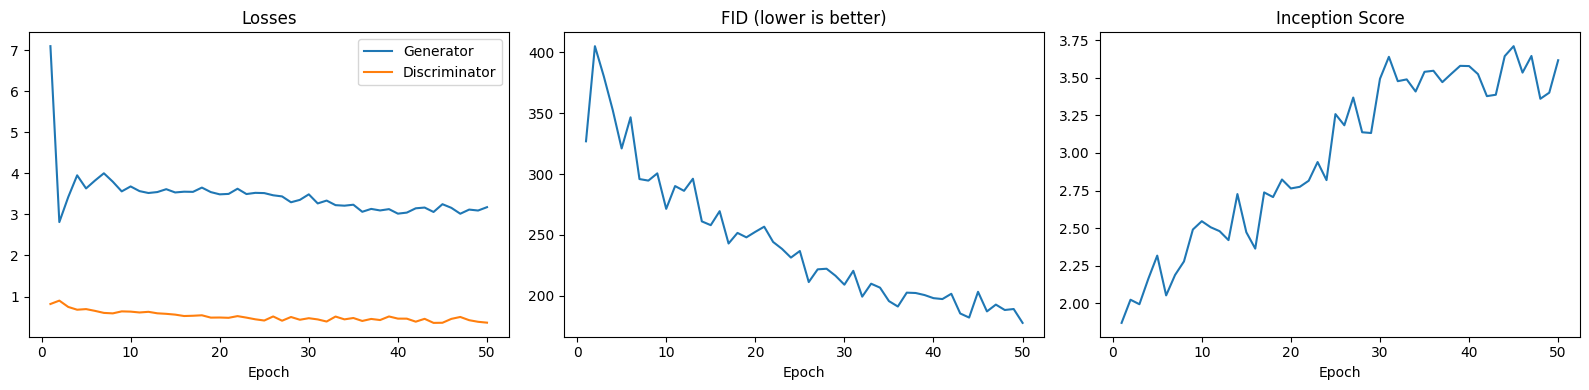

In [78]:
history = dcgan_trainer.train(dataloader, epochs=50, lr=2e-4)
dcgan_trainer.plot_history()


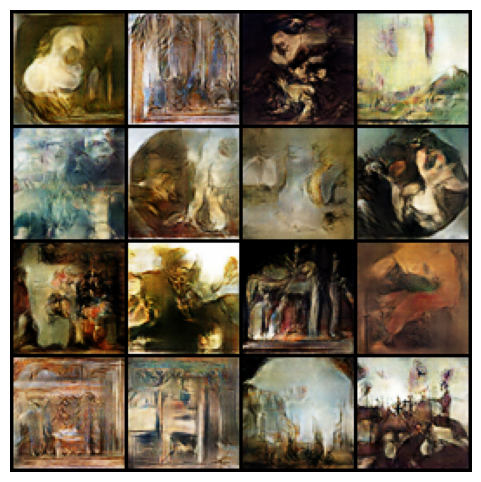

<Figure size 640x480 with 0 Axes>

In [79]:
samples = dcgan_trainer.sample(16).cpu()
grid = (samples + 1) / 2  # back to [0,1] for matplotlib

# samples = dcgan_trainer.sample(16).cpu()
# grid = (samples + 1) / 2  # back to [0,1] for display
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(make_grid(grid, nrow=4).permute(1, 2, 0).numpy())
ax.axis("off")
plt.show()

plt.savefig(f'output_{p}.png', bbox_inches='tight', dpi=150)

In [80]:
dcgan_trainer.save_checkpoint("model/checkpoints/dcgan_64.pt")

AttributeError: 'ArtGANTrainer' object has no attribute 'save_checkpoint'

In [81]:
torch.save(
    {
        "generator_state": dcgan_trainer.generator.state_dict(),
        "discriminator_state": dcgan_trainer.discriminator.state_dict(),
        "mode": dcgan_trainer.mode,
        "image_size": dcgan_trainer.image_size,
        "channels": dcgan_trainer.channels,
        "latent_dim": dcgan_trainer.latent_dim,
    },
    "model/checkpoints/dcgan_64.pt",
)

In [82]:
import torch

ckpt = torch.load("model/checkpoints/dcgan_64.pt", map_location="cpu")
print(sorted(ckpt.keys()))

['channels', 'discriminator_state', 'generator_state', 'image_size', 'latent_dim', 'mode']


### training on WGAN-GP + résidus

In [83]:
wgan_trainer = ArtGANTrainer(
      mode="excellent",
      image_size=64,
      early_stopping_metric="fid",
      early_stopping_patience=10,
      fid_every=1,
      fid_samples=256,
)

/Users/julienrm/.pyenv/versions/ganisme/lib/python3.12/site-packages/torchmetrics/utilities/prints.py:43: UserWarning: Metric `InceptionScore` will save all extracted features in buffer. For large datasets this may lead to large memory footprint.
  warnings.warn(*args, **kwargs)


In [ ]:
history = wgan_trainer.train(dataloader, epochs=50, lr=2e-4)
wgan_trainer.plot_history()


In [ ]:
samples = wgan_trainer.sample(16).cpu()
grid = (samples + 1) / 2  # back to [0,1] for matplotlib

# samples = wgan_trainer.sample(16).cpu()
# grid = (samples + 1) / 2  # back to [0,1] for display
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(make_grid(grid, nrow=4).permute(1, 2, 0).numpy())
ax.axis("off")
plt.show()

plt.savefig(f'output_{p}.png', bbox_inches='tight', dpi=150)